# __Wearable dataset - predicting the physiological state (with per-patient normalized features)__

Ilina Durakovska

__Dataset:__ Wearable Device Dataset from Induced Stress and Structured Exercise Sessions \
__Physionet Link:__ [https://physionet.org/content/wearable-device-dataset/1.0.1/](https://physionet.org/content/wearable-device-dataset/1.0.1/) \
__Kaggle (unofficial) Link:__ [https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise](https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise)

This notebook mirrors `wearable_stress_prediction.ipynb`, but trains on `wearable_dataset_windows_normalized.csv` instead of the original windowed CSV. That file has all the same columns as before, plus 9 new `delta_*` columns - each one is a HeartPy/EDA/TEMP feature expressed as *this window's value minus that patient's own resting-state average for that feature* (computed and explained in the preprocessing notebook). The goal is to see whether giving the models a per-patient-normalized view of the signal (instead of only raw absolute values) helps them generalize better across patients in the LOPO evaluation below.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras import layers, models, callbacks
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
warnings.filterwarnings("ignore")

---

## __Loading and prepping the data:__

In [16]:
df = pd.read_csv("wearable_dataset_windows_normalized.csv")

delta_cols = [c for c in df.columns if c.startswith("delta_")]
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"{len(delta_cols)} delta columns found:")
print(delta_cols)

Loaded 37652 rows, 38 columns.
9 delta columns found:
['delta_hp_bpm', 'delta_hp_ibi', 'delta_hp_sdnn', 'delta_hp_rmssd', 'delta_hp_hr_mad', 'delta_hp_breathingrate', 'delta_eda_mean', 'delta_eda_phasic_mean', 'delta_temp_mean']


When making the windows, some subjects had missaligned labels that did not match the protocols that were described. To make sure this does not pollute our data, we filter out their sessions just to be safe - same as before.

In [19]:
print(f"In total, there are: {len(df)} windows before filtering.")

In total, there are: 37652 windows before filtering.


In [21]:
MISALIGNED_SESSIONS = {
    ("S03", "AEROBIC"),
    ("S07", "AEROBIC"),
    ("S11", "AEROBIC"),
    ("S06", "ANAEROBIC"),
    ("S16", "ANAEROBIC"),
}

In [23]:
df = df[
    ~df.apply(lambda r: (r["patient_id"], r["session"]) in MISALIGNED_SESSIONS, axis=1)
].reset_index(drop=True)

print(f"Dropped misaligned sessions, {len(df)} windows remain.")

Dropped misaligned sessions, 36320 windows remain.


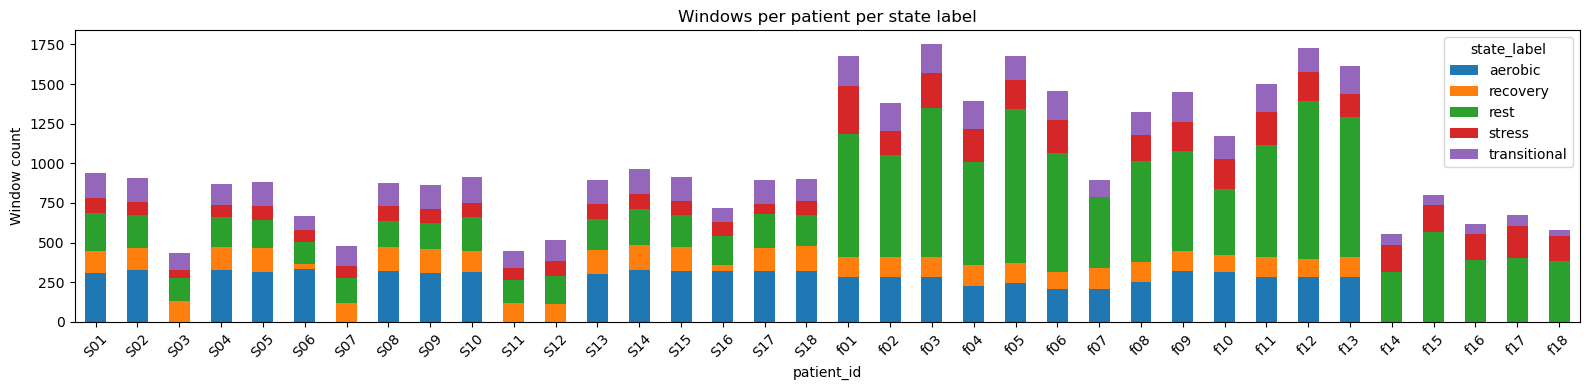

In [25]:
counts = df.groupby(["patient_id", "state_label"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=True, figsize=(16, 4))
plt.title("Windows per patient per state label")
plt.ylabel("Window count")
plt.xticks(rotation=45)
plt.tight_layout()

---

## __Random Forest__

The training and evaluation will be done using the Leave-One-Patient-Out (LOPO) strategy. We train on data from all but one patient, and predict the labels of the last patient. We do this for each patient one by one, then look at their individual and averaged metrics.

`EXCLUDE_COLS` is unchanged from the original notebook - it only strips out IDs/metadata, so the new `delta_*` columns automatically flow into `feature_cols` alongside the raw ones without any extra work here.

In [39]:
EXCLUDE_COLS = {
    "patient_id", "session", "phase", "state_label", "state_label_int",
    "window_index", "t_start_sec", "t_end_sec",
    "hp_quality_flag", "motion_artifact_flag", "tags_misaligned",
}

In [19]:
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

In [35]:
def prepare_data(df):
    clean = df.copy()

    if "state_label" in clean.columns:
        clean = clean[clean["state_label"] != "transitional"]

    if "tags_misaligned" in clean.columns:
        clean = clean[~clean["tags_misaligned"]]

    feature_cols = [c for c in clean.columns if c not in EXCLUDE_COLS]

    clean["hp_sd1/sd2"] = clean["hp_sd1/sd2"].replace([np.inf, -np.inf], np.nan)
    clean["hp_sd1/sd2"] = clean["hp_sd1/sd2"].fillna(clean["hp_sd1/sd2"].max())

    clean = clean.dropna(subset=feature_cols)

    X = clean[feature_cols]
    y = clean["state_label"]
    groups = clean["patient_id"]

    return X, y, groups, feature_cols

In [21]:
def run_one_fold(X, y, groups, test_patient, rf_params=RF_PARAMS):
    """
    Train on everyone except `test_patient`, test on `test_patient`.
    Returns a dict of metrics plus the fitted model and predictions.
    """
    train_mask = groups != test_patient
    test_mask = groups == test_patient

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        return None

    model = RandomForestClassifier(**rf_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    result = {
        "patient_id": test_patient,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "y_true": y_test.values,
        "y_pred": y_pred,
        "model": model,
    }
    return result

In [22]:
def run_lopo_cv(df, rf_params=RF_PARAMS, verbose=True):
    """
    Leave-one-patient-out cross-validation over the whole dataframe.
    Returns (fold_results: list[dict], summary_df: pd.DataFrame)
    """
    X, y, groups, feature_cols = prepare_data(df)
    patients = sorted(groups.unique())

    fold_results = []
    for pid in patients:
        res = run_one_fold(X, y, groups, pid, rf_params=rf_params)
        if res is None:
            if verbose:
                print(f"  [{pid}] skipped — no test windows")
            continue
        fold_results.append(res)
        if verbose:
            print(f"  [{pid}] n_train={res['n_train']:>5}  n_test={res['n_test']:>4}  "
                  f"acc={res['accuracy']:.3f}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"f1_macro={res['f1_macro']:.3f}")

    summary_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("y_true", "y_pred", "model")}
        for r in fold_results
    ])

    return fold_results, summary_df

In [44]:
def summarize_lopo(fold_results, summary_df):
    """
    Print averaged metrics across all folds, plus an overall (pooled)
    classification report and confusion matrix built from every fold's
    held-out predictions concatenated together.
    """
    print("\n=== Per-metric average across patients (mean ± std) ===")
    for metric in ["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted"]:
        vals = summary_df[metric]
        print(f"{metric:>20}: {vals.mean():.3f} ± {vals.std():.3f}")

    all_true = np.concatenate([r["y_true"] for r in fold_results])
    all_pred = np.concatenate([r["y_pred"] for r in fold_results])

    print("\n=== Pooled classification report (all held-out folds combined) ===")
    print(classification_report(all_true, all_pred, zero_division=0))

    labels = sorted(pd.unique(np.concatenate([all_true, all_pred])))
    cm = confusion_matrix(all_true, all_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print("=== Pooled confusion matrix ===")
    print(cm_df)

    return cm_df

In [24]:
fold_results, summary_df = run_lopo_cv(df)

  [S01] n_train=30639  n_test= 783  acc=0.455  bal_acc=0.394  f1_macro=0.330
  [S02] n_train=30668  n_test= 754  acc=0.626  bal_acc=0.477  f1_macro=0.447
  [S03] n_train=31094  n_test= 328  acc=0.412  bal_acc=0.310  f1_macro=0.205
  [S04] n_train=30687  n_test= 735  acc=0.672  bal_acc=0.525  f1_macro=0.504
  [S05] n_train=30691  n_test= 731  acc=0.513  bal_acc=0.396  f1_macro=0.307
  [S06] n_train=30841  n_test= 581  acc=0.408  bal_acc=0.523  f1_macro=0.332
  [S07] n_train=31070  n_test= 352  acc=0.480  bal_acc=0.392  f1_macro=0.257
  [S08] n_train=30689  n_test= 733  acc=0.426  bal_acc=0.382  f1_macro=0.337
  [S09] n_train=30709  n_test= 713  acc=0.351  bal_acc=0.367  f1_macro=0.295
  [S10] n_train=30670  n_test= 752  acc=0.432  bal_acc=0.430  f1_macro=0.324
  [S11] n_train=31079  n_test= 343  acc=0.469  bal_acc=0.376  f1_macro=0.251
  [S12] n_train=31039  n_test= 383  acc=0.634  bal_acc=0.544  f1_macro=0.386
  [S13] n_train=30676  n_test= 746  acc=0.361  bal_acc=0.355  f1_macro=0.261

In [25]:
cm_df = summarize_lopo(fold_results, summary_df)


=== Per-metric average across patients (mean ± std) ===
            accuracy: 0.548 ± 0.119
   balanced_accuracy: 0.431 ± 0.072
            f1_macro: 0.350 ± 0.081
         f1_weighted: 0.488 ± 0.124

=== Pooled classification report (all held-out folds combined) ===
              precision    recall  f1-score   support

     aerobic       0.57      0.41      0.47      7959
    recovery       0.37      0.33      0.35      3905
        rest       0.60      0.87      0.71     14829
      stress       0.32      0.05      0.08      4729

    accuracy                           0.56     31422
   macro avg       0.47      0.41      0.40     31422
weighted avg       0.52      0.56      0.51     31422

=== Pooled confusion matrix ===
          aerobic  recovery   rest  stress
aerobic      3227      1644   3085       3
recovery     1460      1304   1140       1
rest          912       552  12916     449
stress         71         9   4431     218


### _Raw vs. delta feature importance:_

Since the whole point of this notebook is checking whether the per-patient normalized features pull their weight, let's look at averaged Random Forest feature importances across all LOPO folds, with the `delta_*` features highlighted against their raw counterparts.

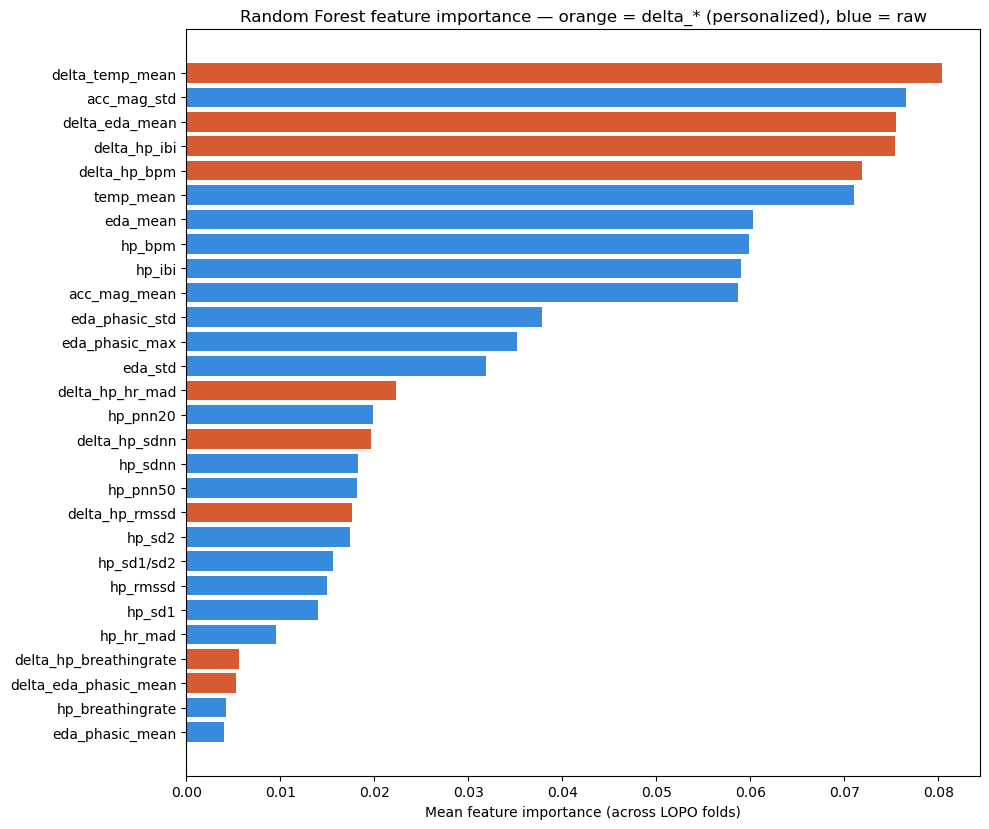

In [27]:
importances = pd.DataFrame([
    r["model"].feature_importances_ for r in fold_results
], columns=prepare_data(df)[3]).mean().sort_values(ascending=False)

colors = ["#D85A30" if c.startswith("delta_") else "#378ADD" for c in importances.index]

plt.figure(figsize=(10, max(6, len(importances) * 0.3)))
plt.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1])
plt.xlabel("Mean feature importance (across LOPO folds)")
plt.title("Random Forest feature importance — orange = delta_* (personalized), blue = raw")
plt.tight_layout()
plt.show()

---

## __SVM__

In [30]:
SVM_PARAMS = dict(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42,
)

In [31]:
def run_one_fold_svm(X, y, groups, test_patient, svm_params=SVM_PARAMS):
    """
    Same idea as run_one_fold, but scales features (fit on train only)
    before handing them to the SVM.
    """
    train_mask = groups != test_patient
    test_mask = groups == test_patient

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = SVC(**svm_params)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    result = {
        "patient_id": test_patient,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "y_true": y_test.values,
        "y_pred": y_pred,
        "model": model,
        "scaler": scaler,
    }
    return result

In [32]:
def run_lopo_cv_svm(df, svm_params=SVM_PARAMS, verbose=True):
    X, y, groups, feature_cols = prepare_data(df)
    patients = sorted(groups.unique())

    fold_results = []
    for pid in patients:
        res = run_one_fold_svm(X, y, groups, pid, svm_params=svm_params)
        if res is None:
            if verbose:
                print(f"  [{pid}] skipped — no test windows")
            continue
        fold_results.append(res)
        if verbose:
            print(f"  [{pid}] n_train={res['n_train']:>5}  n_test={res['n_test']:>4}  "
                  f"acc={res['accuracy']:.3f}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"f1_macro={res['f1_macro']:.3f}")

    summary_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("y_true", "y_pred", "model", "scaler")}
        for r in fold_results
    ])

    return fold_results, summary_df

In [33]:
fold_results_svm, summary_df_svm = run_lopo_cv_svm(df)

  [S01] n_train=30639  n_test= 783  acc=0.378  bal_acc=0.523  f1_macro=0.364
  [S02] n_train=30668  n_test= 754  acc=0.582  bal_acc=0.522  f1_macro=0.448
  [S03] n_train=31094  n_test= 328  acc=0.232  bal_acc=0.319  f1_macro=0.205
  [S04] n_train=30687  n_test= 735  acc=0.430  bal_acc=0.476  f1_macro=0.417
  [S05] n_train=30691  n_test= 731  acc=0.484  bal_acc=0.422  f1_macro=0.435
  [S06] n_train=30841  n_test= 581  acc=0.534  bal_acc=0.542  f1_macro=0.390
  [S07] n_train=31070  n_test= 352  acc=0.284  bal_acc=0.382  f1_macro=0.192
  [S08] n_train=30689  n_test= 733  acc=0.371  bal_acc=0.348  f1_macro=0.332
  [S09] n_train=30709  n_test= 713  acc=0.602  bal_acc=0.610  f1_macro=0.524
  [S10] n_train=30670  n_test= 752  acc=0.573  bal_acc=0.531  f1_macro=0.454
  [S11] n_train=31079  n_test= 343  acc=0.216  bal_acc=0.293  f1_macro=0.169
  [S12] n_train=31039  n_test= 383  acc=0.465  bal_acc=0.536  f1_macro=0.392
  [S13] n_train=30676  n_test= 746  acc=0.414  bal_acc=0.510  f1_macro=0.409

In [34]:
cm_df_svm = summarize_lopo(fold_results_svm, summary_df_svm)


=== Per-metric average across patients (mean ± std) ===
            accuracy: 0.430 ± 0.117
   balanced_accuracy: 0.484 ± 0.108
            f1_macro: 0.365 ± 0.120
         f1_weighted: 0.417 ± 0.122

=== Pooled classification report (all held-out folds combined) ===
              precision    recall  f1-score   support

     aerobic       0.52      0.46      0.49      7959
    recovery       0.31      0.50      0.38      3905
        rest       0.65      0.31      0.42     14829
      stress       0.31      0.73      0.44      4729

    accuracy                           0.43     31422
   macro avg       0.45      0.50      0.43     31422
weighted avg       0.52      0.43      0.43     31422

=== Pooled confusion matrix ===
          aerobic  recovery  rest  stress
aerobic      3655      2935  1058     311
recovery     1389      1950   462     104
rest         1749      1307  4573    7200
stress        186       131   967    3445


---

## __LSTM__

In [37]:
SEQ_LEN = 10       # number of consecutive windows per sequence (10 windows * 5s stride ≈ 50s of extra context)
SEQ_STRIDE = 5      # step between sequence start points, in windows

In [38]:
LSTM_PARAMS = dict(
    units=64,
    dropout=0.3,
    epochs=30,
    batch_size=64,
    patience=5,
)

In [39]:
def prepare_clean_df(df):
    clean = df.copy()

    if "state_label" in clean.columns:
        clean = clean[clean["state_label"] != "transitional"]
    if "tags_misaligned" in clean.columns:
        clean = clean[~clean["tags_misaligned"]]

    feature_cols = [c for c in clean.columns if c not in EXCLUDE_COLS]
    clean[feature_cols] = clean[feature_cols].replace([np.inf, -np.inf], np.nan)
    clean = clean.dropna(subset=feature_cols)

    return clean, feature_cols

In [40]:
def build_sequences(clean_df, feature_cols, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE):
    """
    Groups by (patient_id, session), sorts by time, and slides a length-`seq_len`
    window over the feature rows. Each sequence is labeled with the state_label
    of its *last* row (i.e. "predict the current state given the recent past").
    """
    X_list, y_list, pid_list = [], [], []

    for (pid, session), group in clean_df.groupby(["patient_id", "session"]):
        group = group.sort_values("t_start_sec")
        feats = group[feature_cols].values
        labels = group["state_label"].values

        n = len(group)
        if n < seq_len:
            continue

        for start in range(0, n - seq_len + 1, seq_stride):
            end = start + seq_len
            X_list.append(feats[start:end])
            y_list.append(labels[end - 1])
            pid_list.append(pid)

    X = np.array(X_list)                # (n_sequences, seq_len, n_features)
    y = np.array(y_list)
    groups = np.array(pid_list)
    return X, y, groups

In [41]:
def build_lstm_model(seq_len, n_features, n_classes, params=LSTM_PARAMS):
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(params["units"], return_sequences=False),
        layers.Dropout(params["dropout"]),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [42]:
def run_one_fold_lstm(X, y, groups, test_patient, label_encoder, params=LSTM_PARAMS):
    train_mask = groups != test_patient
    test_mask = groups == test_patient

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        return None

    # scale: fit on train only, flatten to 2D for the scaler then reshape back
    seq_len, n_features = X.shape[1], X.shape[2]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

    y_train_enc = label_encoder.transform(y_train)
    y_test_enc = label_encoder.transform(y_test)

    model = build_lstm_model(seq_len, n_features, len(label_encoder.classes_), params)

    es = callbacks.EarlyStopping(monitor="loss", patience=params["patience"], restore_best_weights=True)
    model.fit(
        X_train_scaled, y_train_enc,
        epochs=params["epochs"], batch_size=params["batch_size"],
        callbacks=[es], verbose=0,
    )

    y_pred_enc = model.predict(X_test_scaled, verbose=0).argmax(axis=1)
    y_pred = label_encoder.inverse_transform(y_pred_enc)

    result = {
        "patient_id": test_patient,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "y_true": y_test,
        "y_pred": y_pred,
        "model": model,
    }
    return result

In [43]:
def run_lopo_cv_lstm(df, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE, params=LSTM_PARAMS, verbose=True):
    clean_df, feature_cols = prepare_clean_df(df)
    X, y, groups = build_sequences(clean_df, feature_cols, seq_len, seq_stride)

    label_encoder = LabelEncoder()
    label_encoder.fit(y)   # fit on all classes up front so encoding is consistent across folds

    patients = sorted(np.unique(groups))
    fold_results = []

    for pid in patients:
        res = run_one_fold_lstm(X, y, groups, pid, label_encoder, params=params)
        if res is None:
            if verbose:
                print(f"  [{pid}] skipped — no test sequences")
            continue
        fold_results.append(res)
        if verbose:
            print(f"  [{pid}] n_train={res['n_train']:>5}  n_test={res['n_test']:>4}  "
                  f"acc={res['accuracy']:.3f}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"f1_macro={res['f1_macro']:.3f}")

    summary_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("y_true", "y_pred", "model")}
        for r in fold_results
    ])

    return fold_results, summary_df

In [44]:
fold_results_lstm, summary_df_lstm = run_lopo_cv_lstm(df)

  [S01] n_train= 6006  n_test= 153  acc=0.392  bal_acc=0.435  f1_macro=0.372
  [S02] n_train= 6012  n_test= 147  acc=0.667  bal_acc=0.685  f1_macro=0.596
  [S03] n_train= 6097  n_test=  62  acc=0.371  bal_acc=0.375  f1_macro=0.294
  [S04] n_train= 6017  n_test= 142  acc=0.542  bal_acc=0.476  f1_macro=0.452
  [S05] n_train= 6017  n_test= 142  acc=0.570  bal_acc=0.464  f1_macro=0.448
  [S06] n_train= 6045  n_test= 114  acc=0.649  bal_acc=0.674  f1_macro=0.566
  [S07] n_train= 6092  n_test=  67  acc=0.567  bal_acc=0.614  f1_macro=0.420
  [S08] n_train= 6016  n_test= 143  acc=0.462  bal_acc=0.466  f1_macro=0.409
  [S09] n_train= 6021  n_test= 138  acc=0.471  bal_acc=0.425  f1_macro=0.388
  [S10] n_train= 6013  n_test= 146  acc=0.493  bal_acc=0.480  f1_macro=0.375
  [S11] n_train= 6093  n_test=  66  acc=0.424  bal_acc=0.341  f1_macro=0.246
  [S12] n_train= 6085  n_test=  74  acc=0.568  bal_acc=0.494  f1_macro=0.383
  [S13] n_train= 6014  n_test= 145  acc=0.400  bal_acc=0.404  f1_macro=0.349

In [45]:
cm_df_lstm = summarize_lopo(fold_results_lstm, summary_df_lstm)


=== Per-metric average across patients (mean ± std) ===
            accuracy: 0.534 ± 0.085
   balanced_accuracy: 0.475 ± 0.084
            f1_macro: 0.409 ± 0.089
         f1_weighted: 0.517 ± 0.084

=== Pooled classification report (all held-out folds combined) ===
              precision    recall  f1-score   support

     aerobic       0.62      0.49      0.54      1571
    recovery       0.35      0.43      0.39       784
        rest       0.63      0.68      0.65      2869
      stress       0.34      0.31      0.32       935

    accuracy                           0.54      6159
   macro avg       0.48      0.48      0.48      6159
weighted avg       0.55      0.54      0.54      6159

=== Pooled confusion matrix ===
          aerobic  recovery  rest  stress
aerobic       765       434   356      16
recovery      244       335   199       6
rest          210       175  1956     528
stress         23        12   614     286


---